# Data Exploratory

- Peak GCVI
- District yield
- Location: India, Season: Kharif

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ee
import geemap
import rasterio as rio
import numpy as np
import geopandas as gpd
import seaborn as sns
import geopandas as gpd

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/edliao/miniconda/envs/research/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.16) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
ee.Authenticate()
ee.Initialize(project='earth-intelligence-492621')

## GCVI

In [3]:
ee.Initialize(project='earth-intelligence-492621')

peak_gcvi = ee.Image('projects/earth-intelligence-492621/assets/peak_gcvi_kharif_2023_mp_cropland_csplus_GAUL24')

geemap.ee_export_image(
    peak_gcvi,
    filename='assets/peak_gcvi_kharif_2023_mp_cropland_csplus.tif',
    scale=500,
    crs='EPSG:4326',
    region=peak_gcvi.geometry(),
)

Generating URL ...
Please wait ...
Data downloaded to /Users/edliao/Documents/6_Projects/crop-yield-forecasting/assets/peak_gcvi_kharif_2023_mp_cropland_csplus.tif


Min: -0.4376634657382965
Max: 26.016948699951172
Dimensions: (1294, 1959)


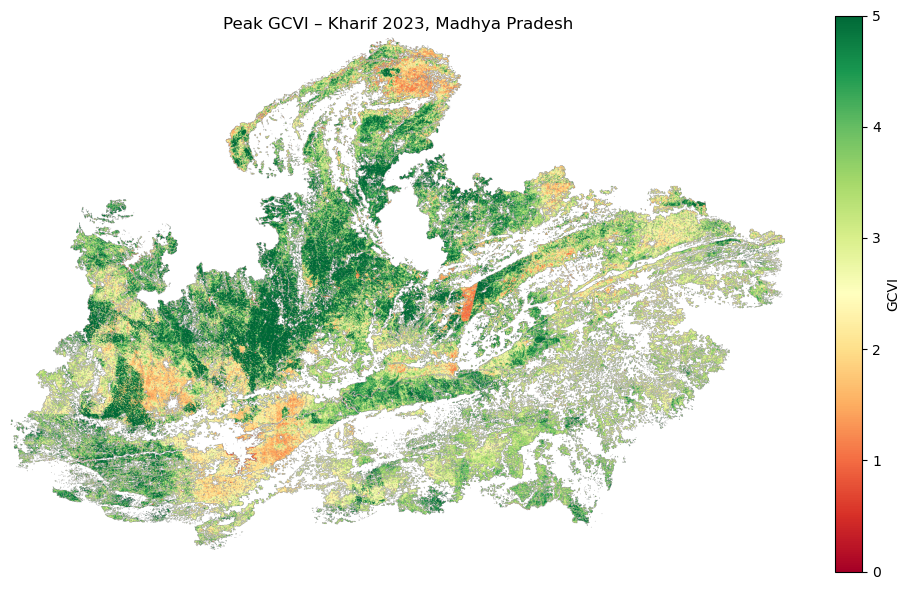

In [2]:
with rio.open('assets/peak_gcvi_kharif_2023_mp_cropland_csplus.tif') as src:
    peak_gcvi = src.read(1).astype('float32')
    # Handle no-data values
    peak_gcvi[peak_gcvi == src.nodata] = np.nan
    # Print basic statistics
    print(f"Min: {peak_gcvi[peak_gcvi>-2].min()}")
    print(f"Max: {peak_gcvi.max()}")
    print(f"Dimensions: {peak_gcvi.shape}")

plt.figure(figsize=(10, 6))
img = plt.imshow(peak_gcvi, cmap='RdYlGn', vmin=0, vmax=5)
plt.colorbar(img, label='GCVI')
plt.title('Peak GCVI – Kharif 2023, Madhya Pradesh')
plt.axis('off')
plt.tight_layout()
plt.show()

In [3]:
# How many pixels fall within different GCVI ranges?
unique, counts = np.unique(np.floor(peak_gcvi), return_counts=True)
for u, c in zip(unique, counts):
    print(f"GCVI {u}: {c} pixels")

GCVI -inf: 1721364 pixels
GCVI -1.0: 58 pixels
GCVI 0.0: 3410 pixels
GCVI 1.0: 78759 pixels
GCVI 2.0: 219439 pixels
GCVI 3.0: 245732 pixels
GCVI 4.0: 139389 pixels
GCVI 5.0: 71839 pixels
GCVI 6.0: 34041 pixels
GCVI 7.0: 13927 pixels
GCVI 8.0: 4872 pixels
GCVI 9.0: 1480 pixels
GCVI 10.0: 407 pixels
GCVI 11.0: 133 pixels
GCVI 12.0: 45 pixels
GCVI 13.0: 13 pixels
GCVI 14.0: 11 pixels
GCVI 15.0: 8 pixels
GCVI 16.0: 5 pixels
GCVI 17.0: 5 pixels
GCVI 18.0: 1 pixels
GCVI 19.0: 3 pixels
GCVI 20.0: 3 pixels
GCVI 23.0: 1 pixels
GCVI 26.0: 1 pixels


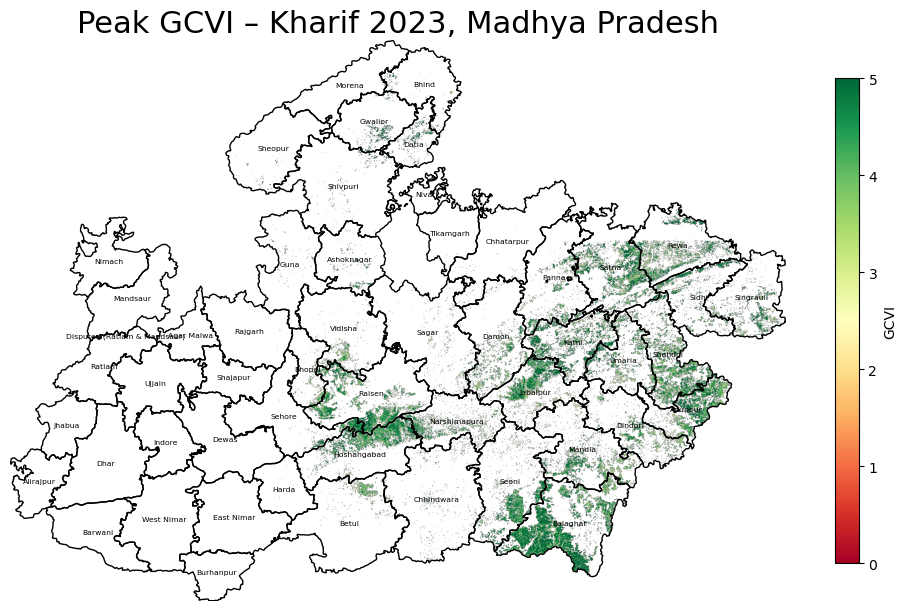

In [3]:
from rasterio.plot import show
import matplotlib.colors as mcolors

districts = gpd.read_file('../../data/MP_Districts_GAUL/MP_Districts_GAUL.shp')
districts = districts.to_crs('EPSG:4326')
fig, ax = plt.subplots(figsize=(10, 10))

with rio.open('../../data/gcvi/peak_gcvi_kharif_2024_mp_crop.tif') as src:
    show(src, ax=ax, cmap='RdYlGn', vmin=0, vmax=5)
    districts = districts.to_crs(src.crs)

districts.plot(ax=ax, color='none', edgecolor='black', linewidth=1)
ax.set_title('Peak GCVI – Kharif 2023, Madhya Pradesh', fontsize=22)

# District name labels
for _, row in districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['gaul2_name'], xy=(centroid.x, centroid.y),
                ha='center', va='center', fontsize=5.5, color='black')

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=mcolors.Normalize(vmin=0, vmax=5))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='GCVI', shrink=0.5)

plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
import rasterio
import numpy as np
from rasterio.plot import show
from rasterstats import zonal_stats

# Step 1: Clean the raster — replace -inf with NaN
input_tif  = '../../data/gcvi/peak_gcvi_kharif_2024_mp_crop.tif'
cleaned_tif = '../../data/gcvi/peak_gcvi_kharif_2024_mp_crop_cleaned.tif'

with rasterio.open(input_tif) as src:
    data = src.read(1).astype(float)
    profile = src.profile
    
    # Replace -inf, inf, and unrealistic values with NaN
    data[np.isinf(data)] = np.nan
    # data[data < 0]       = np.nan  # GCVI shouldn't be negative for crops
    
    profile.update(dtype=rasterio.float32, nodata=np.nan)
    
    with rasterio.open(cleaned_tif, 'w', **profile) as dst:
        dst.write(data.astype(np.float32), 1)

# Step 2: Run zonal stats on cleaned raster
stats = zonal_stats(
    districts,
    cleaned_tif,
    stats=['mean', 'min', 'max', 'median'],
    nodata=np.nan
)

districts['gcvi_mean']   = [s['mean']   for s in stats]
districts['gcvi_median'] = [s['median'] for s in stats]
districts['gcvi_min']    = [s['min']    for s in stats]
districts['gcvi_max']    = [s['max']    for s in stats]

print(districts[['gaul2_name', 'gcvi_mean', 'gcvi_median']].head(10))

   gaul2_name  gcvi_mean  gcvi_median
0  Agar Malwa        NaN          NaN
1   Alirajpur        NaN          NaN
2     Anuppur   5.148458     4.375913
3  Ashoknagar   6.162149     4.441380
4    Balaghat   4.737838     4.756567
5     Barwani        NaN          NaN
6       Betul   3.922689     3.904014
7       Bhind   4.610319     4.731788
8      Bhopal   3.640808     3.735294
9   Burhanpur   4.634648     4.634648


In [37]:
districts.columns

Index(['continent', 'gaul0_name', 'disp_en', 'iso3_code', 'map_code',
       'gaul1_code', 'gaul1_name', 'gaul0_code', 'gaul2_code', 'gaul2_name',
       'geometry', 'gcvi_mean', 'gcvi_median', 'gcvi_min', 'gcvi_max', 'State',
       'District', 'total_area', 'total_production', 'weighted_yield',
       'rice_yield_kg_ha', 'maize_yield_kg_ha', 'rice_area_ha',
       'maize_area_ha', 'rice_area_fraction', 'maize_area_fraction'],
      dtype='object')

In [39]:
# GCVI mean for East Nimar
districts[districts['gaul2_name']=='East Nimar']['gcvi_mean']

18    2.240186
Name: gcvi_mean, dtype: float64

## District Yield Estimates

Source: https://upag.gov.in/dash-reports/desdistrictwisecompletedatasetreport

Units
- Area in Ha
- Production in Tonnes
- Yield kg/Ha

In [10]:
# Explore the district yield data in India for 2023
df = pd.read_csv('../../data/yield/DES-District-Data-For-2022-23-to-2024-25.csv')
df.head()

# Get relevant data: Madhya Pradesh, Kharif, Rice
filtered_data = df[(df['State'] == 'Madhya Pradesh') & (df['Season'] == 'Kharif') & (df['Crop'] == 'Rice')]

# Only get 2024-2025 data column
filtered_data = filtered_data[['District', 'Yield-2024-25']].rename(columns={'Yield-2024-25': 'yield_kg_ha'})

filtered_data

,District,yield_kg_ha
12034,Agar-Malwa,1736.0
12076,Alirajpur,1118.0
12120,Anuppur,1854.0
12166,Ashoknagar,2355.0
12206,Balaghat,2123.0
12251,Barwani,683.0
12294,Betul,2506.0
12340,Bhind,3031.0
12383,Bhopal,2563.0
12426,Burhanpur,1266.0


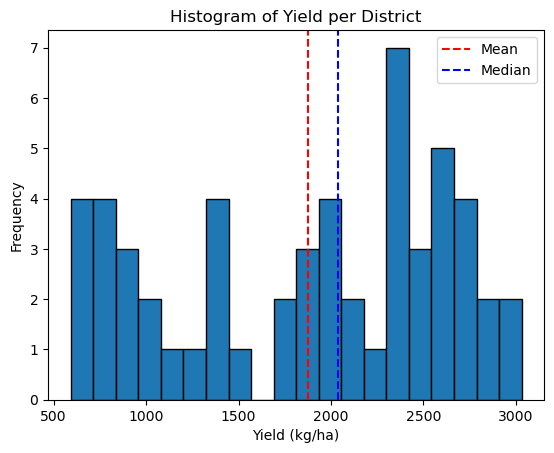

In [12]:
# Generate a histogrram of yield value per district from filtered_data with the mean and median visualized on the figures
plt.hist(filtered_data['yield_kg_ha'], bins=20, edgecolor='black')
plt.axvline(filtered_data['yield_kg_ha'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(filtered_data['yield_kg_ha'].median(), color='blue', linestyle='--', label='Median')
plt.legend()
plt.title('Histogram of Yield per District')
plt.xlabel('Yield (kg/ha)')
plt.ylabel('Frequency')
plt.show()

In [9]:
# Count the crop occurrences in Madhya Pradesh
filtered_data = df[(df['State'] == 'Madhya Pradesh') & (df['Season'] == 'Kharif') ]
filtered_data['Crop'].value_counts()

Crop
Maize                        52
Nutri/Coarse Cereals         52
Cereals                      52
Total Food Grains            52
Jowar                        51
Shree Anna /Nutri Cereals    51
Urad                         51
Moong                        49
Rice                         49
Tur                          48
Bajra                        33
Small Millets                30
Name: count, dtype: int64

Applied filters to get a subset of the district-level yield data:
    - state: Madhya Pradesh
    - season: kharif
    - exclude aggregate crop rows, e.g., cereal, total food grains, nutri/coarse cereals, pulses, oilseeds, and total oilseeds

Output: Weighted average yield (kg/ha)

In [61]:
df = pd.read_csv('data/DES-District-Data-For-2023-24.csv')

# Filter to Kharif only, exclude aggregate crop rows
AGGREGATE_CROPS = {
    'Cereals',
    'Nutri/Coarse Cereals',
    'Shree Anna /Nutri Cereals', 
    'Total Pulses',
    'Total Food Grains',
}

kharif = df[
    (df['State'] == 'Madhya Pradesh') &
    (df['Season'] == 'Kharif') &
    (~df['Crop'].isin(AGGREGATE_CROPS))
].copy()

kharif['Area-2023-24']       = pd.to_numeric(kharif['Area-2023-24'], errors='coerce')
kharif['Production-2023-24'] = pd.to_numeric(kharif['Production-2023-24'], errors='coerce')

# Weighted average yield = total production / total area per district
district_yield = kharif.groupby(['State', 'District']).apply(
    lambda x: pd.Series({
        'total_area':       x['Area-2023-24'].sum(),
        'total_production': x['Production-2023-24'].sum(),
        'weighted_yield':   x['Production-2023-24'].sum() / x['Area-2023-24'].sum()
    })
).reset_index()

district_yield['weighted_yield'] = district_yield['weighted_yield'] * 1000  # Convert yield to kg/ha

# Rice area per district
rice_area = (
    kharif[kharif['Crop'] == 'Rice']
    .groupby('District')['Area-2023-24']
    .sum()
    .rename('rice_area_ha')
    .reset_index()
)

# Maize area per district
maize_area = (
    kharif[kharif['Crop'] == 'Maize']
    .groupby('District')['Area-2023-24']
    .sum()
    .rename('maize_area_ha')
    .reset_index()
)

# Legume area per district
tur_area = (
    kharif[kharif['Crop'] == 'Tur']
    .groupby('District')['Area-2023-24']
    .sum()
    .rename('tur_area_ha')
    .reset_index()
)

# Individual crop yields: rice & maize (Kharif), tur
for crop, col in [('Rice', 'rice_yield_kg_ha'), ('Maize', 'maize_yield_kg_ha'), ('Tur', 'tur_yield_kg_ha')]:
    crop_yield = (
        kharif[kharif['Crop'] == crop]
        .groupby('District')['Yield-2023-24']
        .first()
        .rename(col)
        .reset_index()
    )
    district_yield = district_yield.merge(crop_yield, on='District', how='left')

district_yield = district_yield.merge(rice_area, on='District', how='left')
district_yield = district_yield.merge(maize_area, on='District', how='left')
district_yield = district_yield.merge(tur_area, on='District', how='left')
district_yield['rice_area_ha'] = district_yield['rice_area_ha'].fillna(0)
district_yield['maize_area_ha'] = district_yield['maize_area_ha'].fillna(0)
district_yield['tur_area_ha'] = district_yield['tur_area_ha'].fillna(0)
district_yield['rice_area_fraction'] = district_yield['rice_area_ha'] / district_yield['total_area']
district_yield['maize_area_fraction'] = district_yield['maize_area_ha'] / district_yield['total_area']
district_yield['tur_area_fraction'] = district_yield['tur_area_ha'] / district_yield['total_area']

district_yield.head(10)

/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_14124/899455643.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  district_yield = kharif.groupby(['State', 'District']).apply(


,State,District,total_area,total_production,weighted_yield,rice_yield_kg_ha,maize_yield_kg_ha,tur_yield_kg_ha,rice_area_ha,maize_area_ha,tur_area_ha,rice_area_fraction,maize_area_fraction,tur_area_fraction
0,Madhya Pradesh,Agar-Malwa,1457.92,2703.37,1854.264980,NaN,2880.0,757.0,0.00,817.96,115.00,0.000000,0.561046,0.078879
1,Madhya Pradesh,Alirajpur,68405.84,112017.79,1637.547174,1441.0,2788.0,670.0,4067.09,28428.44,3295.98,0.059455,0.415585,0.048183
2,Madhya Pradesh,Anuppur,142591.18,205430.14,1440.693176,1486.0,2274.0,780.0,119003.58,5039.72,2243.99,0.834579,0.035344,0.015737
3,Madhya Pradesh,Ashoknagar,59013.51,99943.38,1693.567795,2167.0,2790.0,NaN,24924.84,12896.29,0.00,0.422358,0.218531,0.000000
4,Madhya Pradesh,Balaghat,257019.34,468149.06,1821.454603,1837.0,3038.0,1025.0,250344.86,875.95,190.00,0.974031,0.003408,0.000739
5,Madhya Pradesh,Barwani,87050.05,231916.72,2664.176758,1144.0,2930.0,1003.0,74.49,64124.48,1247.99,0.000856,0.736639,0.014336
6,Madhya Pradesh,Betul,215296.19,583684.37,2711.076169,1755.0,2994.0,753.0,29577.84,174707.41,8049.95,0.137382,0.811475,0.037390
7,Madhya Pradesh,Bhind,106368.38,288982.06,2716.804186,2578.0,3147.0,1068.0,28535.75,9.00,41.00,0.268273,0.000085,0.000385
8,Madhya Pradesh,Bhopal,25754.67,53955.72,2094.987822,2185.0,2442.0,905.0,22937.75,820.95,16.00,0.890625,0.031876,0.000621
9,Madhya Pradesh,Burhanpur,19941.34,49429.53,2478.746664,1192.0,3002.0,945.0,220.14,14067.23,4601.97,0.011039,0.705431,0.230775


In [62]:
# Compare the district names in the yield data and the districts geodataframe
yield_districts    = set(district_yield['District'].str.strip().str.title())
gaul_districts     = set(districts['gaul2_name'].str.strip().str.title())

in_yield_not_gaul  = yield_districts - gaul_districts
in_gaul_not_yield  = gaul_districts - yield_districts
matched            = yield_districts & gaul_districts

print(f"Matched: {len(matched)}")
print(f"\nIn yield data but not in GAUL:\n", in_yield_not_gaul)
print(f"\nIn GAUL but not in yield data:\n", in_gaul_not_yield)

Matched: 45

In yield data but not in GAUL:
 {'Narsimhapur', 'Niwari', 'Neemuch', 'Khargone (West Nimar)', 'Agar-Malwa', 'Narmadapuram', 'Khandwa (East Nimar)'}

In GAUL but not in yield data:
 {'East Nimar', 'Agar Malwa', 'Nivari', 'Nimach', 'Hoshangabad', 'Narshimapura', 'Disputed (Ratlam & Mandsaur)', 'West Nimar'}


In [63]:
name_mapping = {
    "Narsimhapur":           "Narshimapura",
    "Khargone (West Nimar)": "West Nimar",
    "Khandwa (East Nimar)":  "East Nimar",
    "Narmadapuram":          "Hoshangabad",
    "Niwari":                "Nivari",
    "Neemuch":               "Nimach",
    "Agar-Malwa":            "Agar Malwa",
}
district_yield['District'] = district_yield['District'].replace(name_mapping)

**Merge data**

In [64]:
# Add yield data to the district geometries
districts['gaul2_name'] = districts['gaul2_name'].str.strip().str.title()
district_yield['District'] = district_yield['District'].str.strip().str.title()

districts = districts.merge(
    district_yield,
    left_on='gaul2_name',
    right_on='District',
    how='left'
)

print(f"Matched: {districts['District'].notna().sum()} / {len(districts)}")



Matched: 52 / 53


In [65]:
# Remove the disputed district
districts = districts[districts['gaul2_name'] != 'Disputed (Ratlam & Mandsaur)']
districts

,continent,gaul0_name,disp_en,iso3_code,map_code,gaul1_code,gaul1_name,gaul0_code,gaul2_code,gaul2_name,...,weighted_yield,rice_yield_kg_ha,maize_yield_kg_ha,tur_yield_kg_ha,rice_area_ha,maize_area_ha,tur_area_ha,rice_area_fraction,maize_area_fraction,tur_area_fraction
0,Asia,India,"Agar Malwa, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125573,Agar Malwa,...,1854.264980,NaN,2880.0,757.0,0.00,817.96,115.00,0.000000,0.561046,0.078879
1,Asia,India,"Alirajpur, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125574,Alirajpur,...,1637.547174,1441.0,2788.0,670.0,4067.09,28428.44,3295.98,0.059455,0.415585,0.048183
2,Asia,India,"Anuppur, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125575,Anuppur,...,1440.693176,1486.0,2274.0,780.0,119003.58,5039.72,2243.99,0.834579,0.035344,0.015737
3,Asia,India,"Ashoknagar, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125576,Ashoknagar,...,1693.567795,2167.0,2790.0,NaN,24924.84,12896.29,0.00,0.422358,0.218531,0.000000
4,Asia,India,"Balaghat, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125577,Balaghat,...,1821.454603,1837.0,3038.0,1025.0,250344.86,875.95,190.00,0.974031,0.003408,0.000739
5,Asia,India,"Barwani, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125578,Barwani,...,2664.176758,1144.0,2930.0,1003.0,74.49,64124.48,1247.99,0.000856,0.736639,0.014336
6,Asia,India,"Betul, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125579,Betul,...,2711.076169,1755.0,2994.0,753.0,29577.84,174707.41,8049.95,0.137382,0.811475,0.037390
7,Asia,India,"Bhind, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125580,Bhind,...,2716.804186,2578.0,3147.0,1068.0,28535.75,9.00,41.00,0.268273,0.000085,0.000385
8,Asia,India,"Bhopal, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125581,Bhopal,...,2094.987822,2185.0,2442.0,905.0,22937.75,820.95,16.00,0.890625,0.031876,0.000621
9,Asia,India,"Burhanpur, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125582,Burhanpur,...,2478.746664,1192.0,3002.0,945.0,220.14,14067.23,4601.97,0.011039,0.705431,0.230775


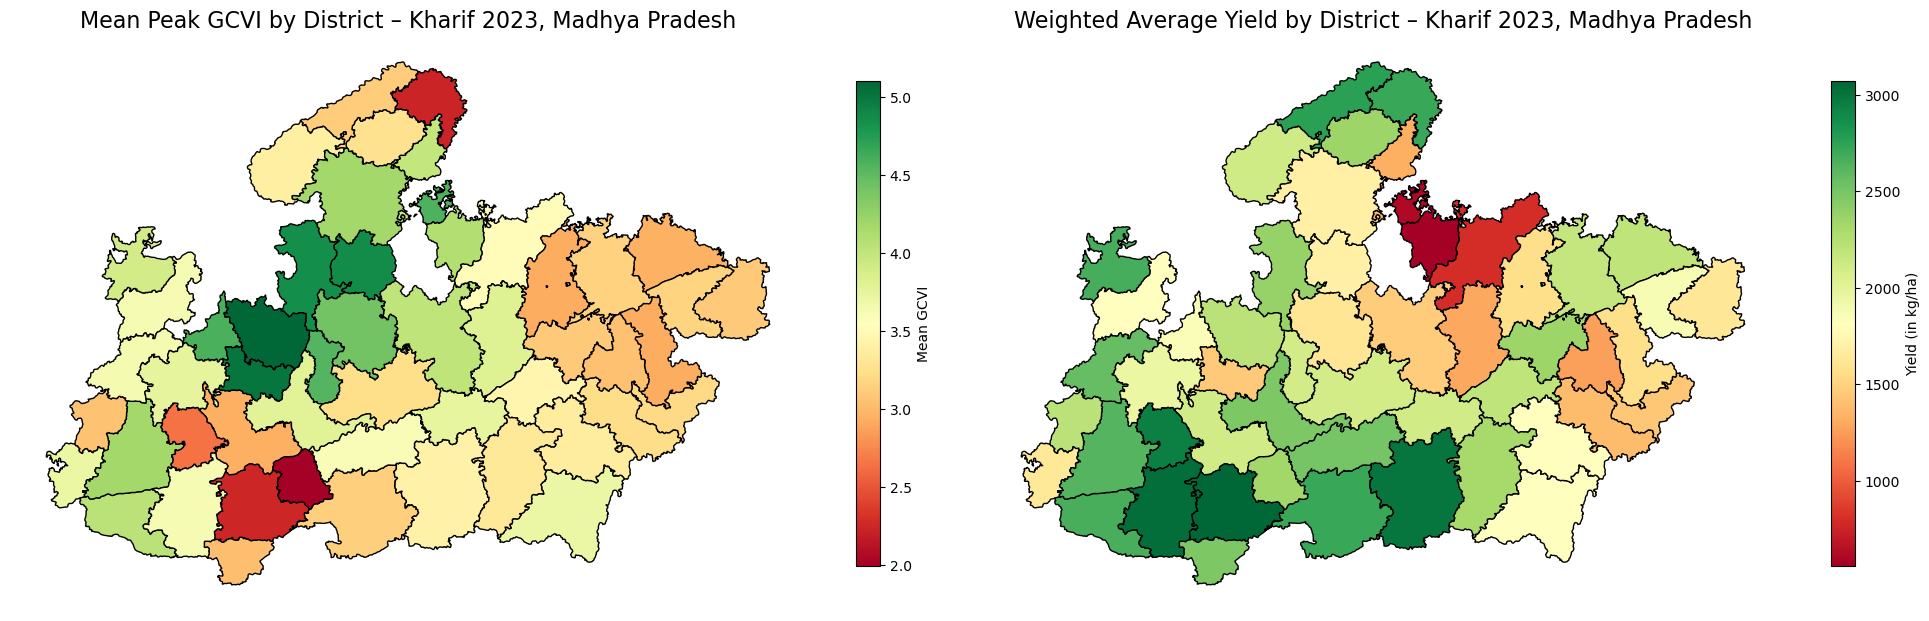

In [15]:
# Generate a map showing mean GCVI by district and a map of yield by district
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
districts.plot(column='gcvi_mean', ax=ax[0], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Mean GCVI'})
ax[0].set_title('Mean Peak GCVI by District – Kharif 2023, Madhya Pradesh', fontsize=16)
ax[0].axis('off')
districts.plot(column='weighted_yield', ax=ax[1], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Yield (in kg/ha)'})
ax[1].set_title('Weighted Average Yield by District – Kharif 2023, Madhya Pradesh', fontsize=16)
ax[1].axis('off')
plt.tight_layout()
plt.show()

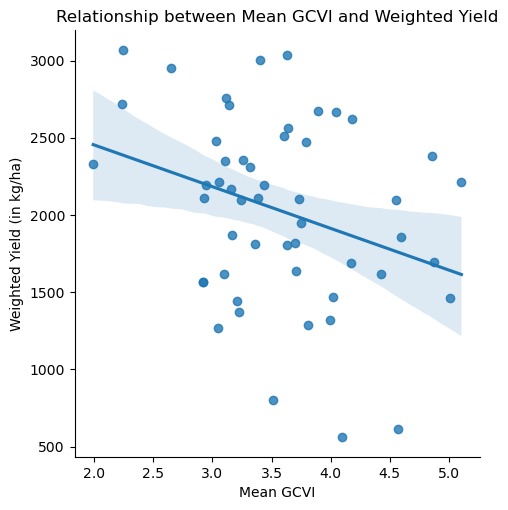

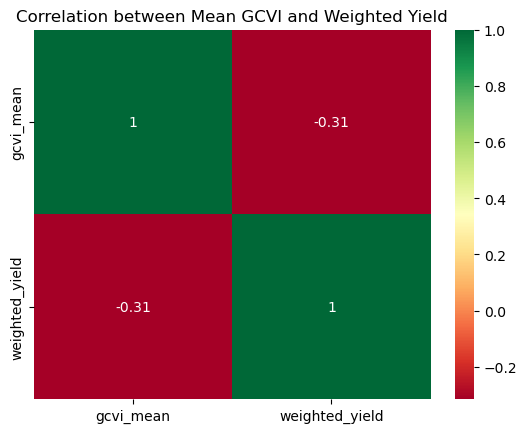

In [16]:
# Plot the relationship between Mean GCVI and Weighted Yield with the best fit line
sns.lmplot(x='gcvi_mean', y='weighted_yield', data=districts)
plt.title('Relationship between Mean GCVI and Weighted Yield')
plt.xlabel('Mean GCVI')
plt.ylabel('Weighted Yield (in kg/ha)')
plt.show()

# Compute the correlation between Mean GCVI and Weighted Yield
correlation = districts[['gcvi_mean', 'weighted_yield']].corr()
sns.heatmap(correlation, annot=True, cmap='RdYlGn')
plt.title('Correlation between Mean GCVI and Weighted Yield')
plt.show()

### Individual crop analysis
Filters
- State: Madhya Pradesh
- Season: Kharif
- Crops: Rice, Maize

In [17]:
districts

,continent,gaul0_name,disp_en,iso3_code,map_code,gaul1_code,gaul1_name,gaul0_code,gaul2_code,gaul2_name,...,District,total_area,total_production,weighted_yield,rice_yield_kg_ha,maize_yield_kg_ha,rice_area_ha,maize_area_ha,rice_area_fraction,maize_area_fraction
0,Asia,India,"Agar Malwa, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125573,Agar Malwa,...,Agar Malwa,1457.92,2703.37,1854.264980,NaN,2880.0,0.00,817.96,0.000000,0.561046
1,Asia,India,"Alirajpur, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125574,Alirajpur,...,Alirajpur,68405.84,112017.79,1637.547174,1441.0,2788.0,4067.09,28428.44,0.059455,0.415585
2,Asia,India,"Anuppur, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125575,Anuppur,...,Anuppur,142591.18,205430.14,1440.693176,1486.0,2274.0,119003.58,5039.72,0.834579,0.035344
3,Asia,India,"Ashoknagar, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125576,Ashoknagar,...,Ashoknagar,59013.51,99943.38,1693.567795,2167.0,2790.0,24924.84,12896.29,0.422358,0.218531
4,Asia,India,"Balaghat, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125577,Balaghat,...,Balaghat,257019.34,468149.06,1821.454603,1837.0,3038.0,250344.86,875.95,0.974031,0.003408
5,Asia,India,"Barwani, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125578,Barwani,...,Barwani,87050.05,231916.72,2664.176758,1144.0,2930.0,74.49,64124.48,0.000856,0.736639
6,Asia,India,"Betul, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125579,Betul,...,Betul,215296.19,583684.37,2711.076169,1755.0,2994.0,29577.84,174707.41,0.137382,0.811475
7,Asia,India,"Bhind, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125580,Bhind,...,Bhind,106368.38,288982.06,2716.804186,2578.0,3147.0,28535.75,9.00,0.268273,0.000085
8,Asia,India,"Bhopal, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125581,Bhopal,...,Bhopal,25754.67,53955.72,2094.987822,2185.0,2442.0,22937.75,820.95,0.890625,0.031876
9,Asia,India,"Burhanpur, Madhya Pradesh, India",IND,IND,2598,Madhya Pradesh,240,125582,Burhanpur,...,Burhanpur,19941.34,49429.53,2478.746664,1192.0,3002.0,220.14,14067.23,0.011039,0.705431


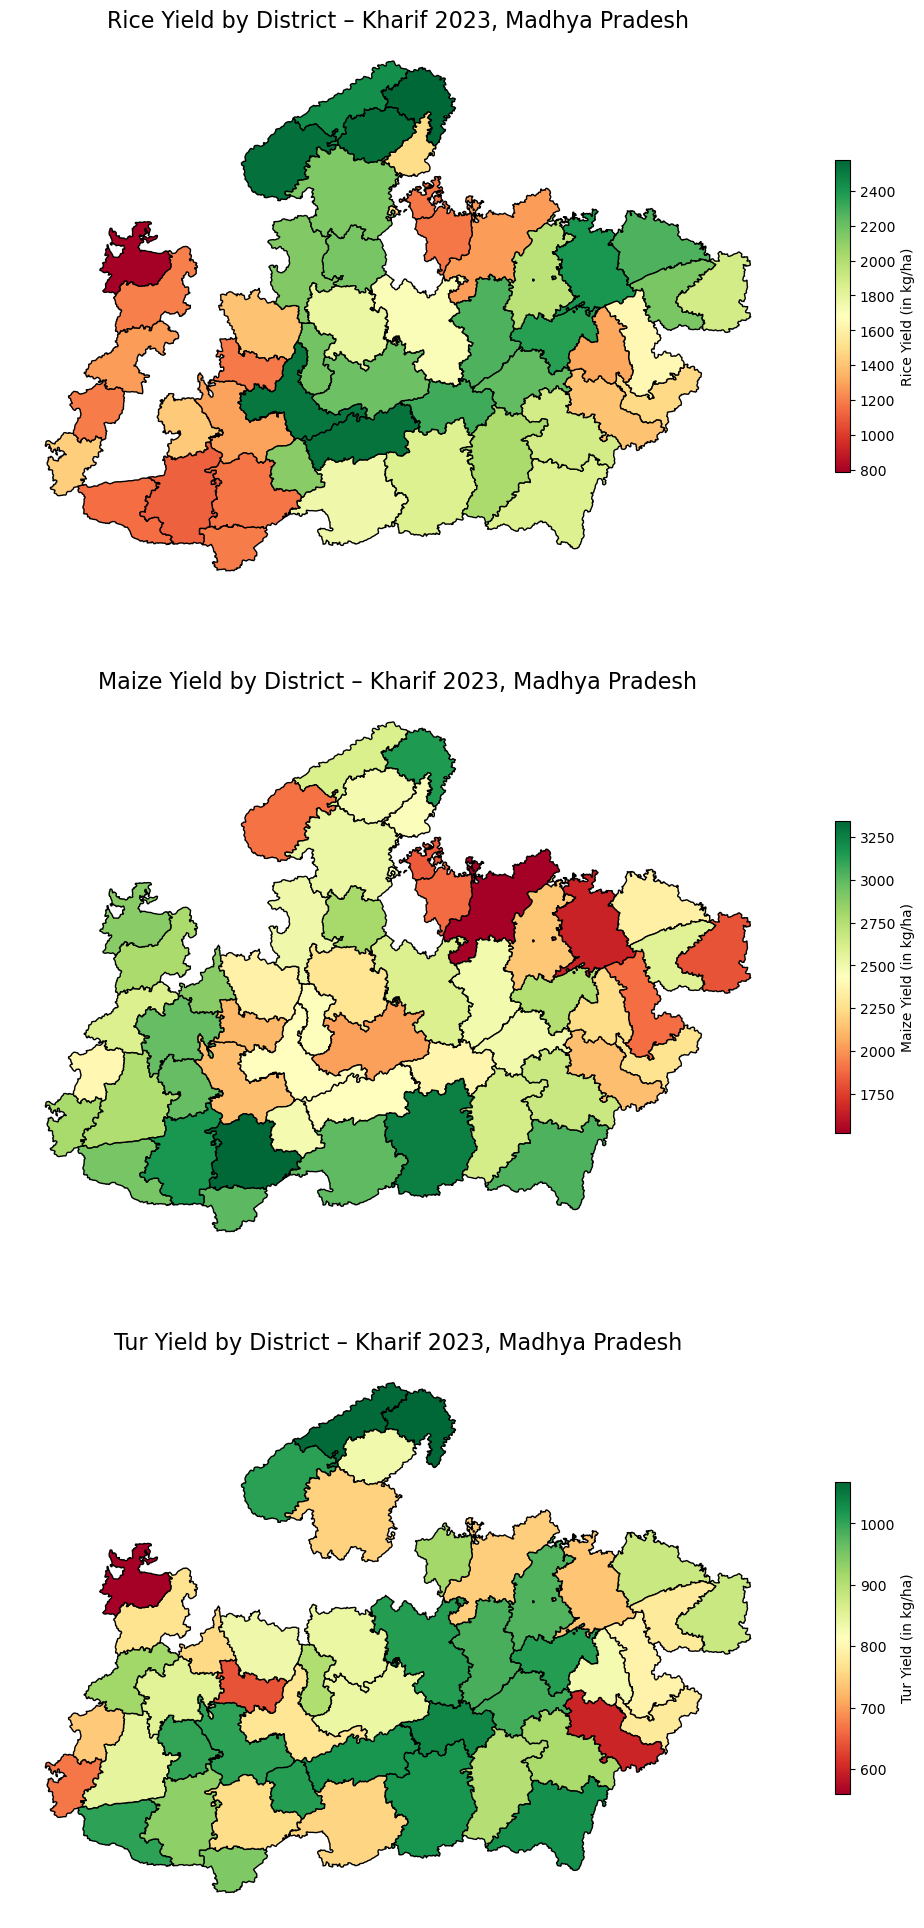

In [68]:
# Generate a map showing mean GCVI by district and a map of yield by district and the rice and maize yield by district
fig, ax = plt.subplots(3, 1, figsize=(10, 20))

districts.plot(column='rice_yield_kg_ha', ax=ax[0], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Rice Yield (in kg/ha)'})
ax[0].set_title('Rice Yield by District – Kharif 2023, Madhya Pradesh', fontsize=16)

districts.plot(column='maize_yield_kg_ha', ax=ax[1], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Maize Yield (in kg/ha)'})
ax[1].set_title('Maize Yield by District – Kharif 2023, Madhya Pradesh', fontsize=16)

districts.plot(column='tur_yield_kg_ha', ax=ax[2], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Tur Yield (in kg/ha)'})
ax[2].set_title('Tur Yield by District – Kharif 2023, Madhya Pradesh', fontsize=16)

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
plt.tight_layout()
plt.show()

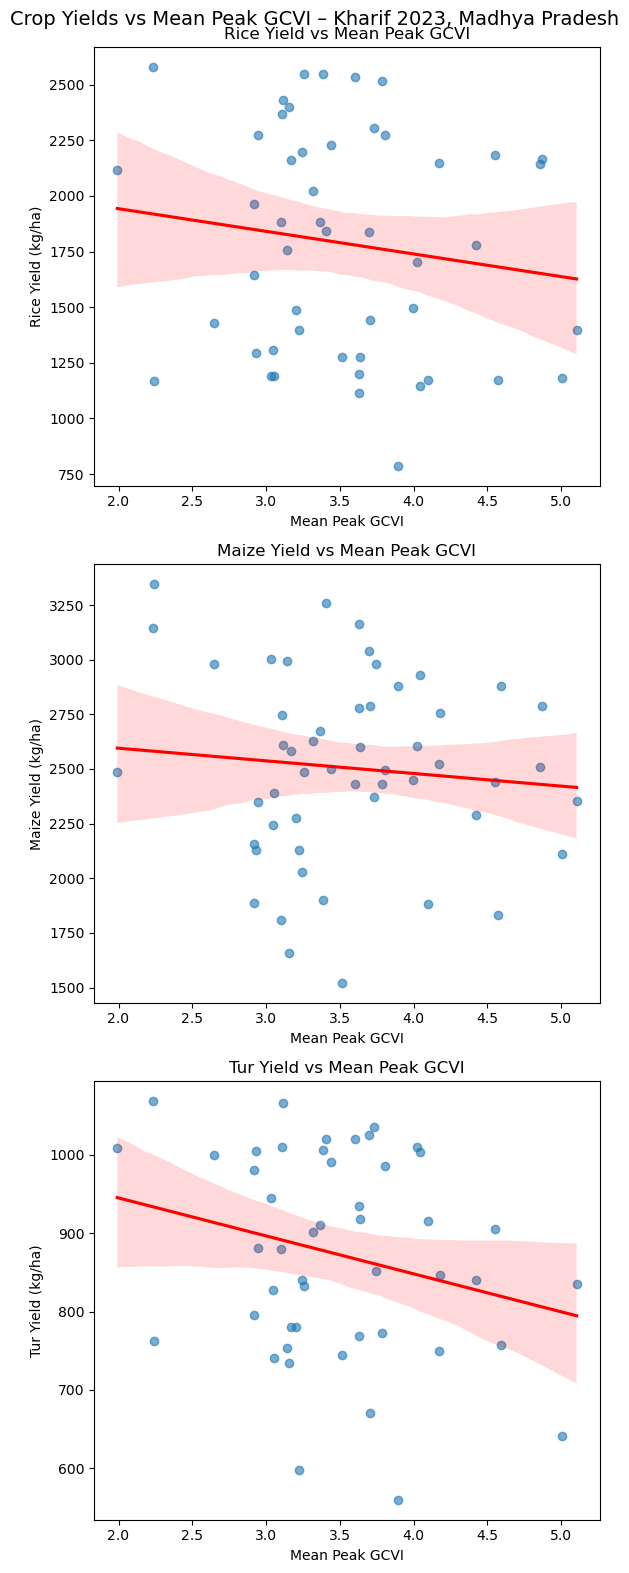

In [72]:
import seaborn as sns

fig, ax = plt.subplots(3, 1, figsize=(6, 16))

sns.regplot(data=districts, x='gcvi_mean', y='rice_yield_kg_ha', ax=ax[0],
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
ax[0].set_title('Rice Yield vs Mean Peak GCVI')
ax[0].set_xlabel('Mean Peak GCVI')
ax[0].set_ylabel('Rice Yield (kg/ha)')

sns.regplot(data=districts, x='gcvi_mean', y='maize_yield_kg_ha', ax=ax[1],
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
ax[1].set_title('Maize Yield vs Mean Peak GCVI')
ax[1].set_xlabel('Mean Peak GCVI')
ax[1].set_ylabel('Maize Yield (kg/ha)')

sns.regplot(data=districts, x='gcvi_mean', y='tur_yield_kg_ha', ax=ax[2],
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
ax[2].set_title('Tur Yield vs Mean Peak GCVI')
ax[2].set_xlabel('Mean Peak GCVI')
ax[2].set_ylabel('Tur Yield (kg/ha)')

plt.suptitle('Crop Yields vs Mean Peak GCVI – Kharif 2023, Madhya Pradesh', fontsize=14)
plt.tight_layout()
plt.show()

Rice  — r: -0.140,  p: 0.338
Maize — r: -0.095, p: 0.501
Tur   — r: -0.244,   p: 0.095


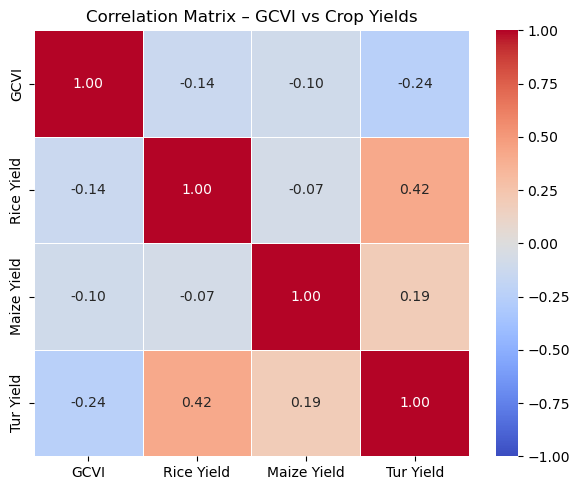

In [73]:
import scipy.stats as stats

# Compute correlations (drop NaN rows for each crop)
rice_data  = districts[['gcvi_mean', 'rice_yield_kg_ha']].dropna()
maize_data = districts[['gcvi_mean', 'maize_yield_kg_ha']].dropna()
tur_data   = districts[['gcvi_mean', 'tur_yield_kg_ha']].dropna()

rice_r,  rice_p  = stats.pearsonr(rice_data['gcvi_mean'],  rice_data['rice_yield_kg_ha'])
maize_r, maize_p = stats.pearsonr(maize_data['gcvi_mean'], maize_data['maize_yield_kg_ha'])
tur_r,   tur_p   = stats.pearsonr(tur_data['gcvi_mean'],   tur_data['tur_yield_kg_ha'])

print(f"Rice  — r: {rice_r:.3f},  p: {rice_p:.3f}")
print(f"Maize — r: {maize_r:.3f}, p: {maize_p:.3f}")
print(f"Tur   — r: {tur_r:.3f},   p: {tur_p:.3f}")

# Visualize correlation matrix
corr_df = districts[['gcvi_mean', 'rice_yield_kg_ha', 'maize_yield_kg_ha', 'tur_yield_kg_ha']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=ax, linewidths=0.5,
            xticklabels=['GCVI', 'Rice Yield', 'Maize Yield', 'Tur Yield'],
            yticklabels=['GCVI', 'Rice Yield', 'Maize Yield', 'Tur Yield'])
ax.set_title('Correlation Matrix – GCVI vs Crop Yields')
plt.tight_layout()
plt.show()

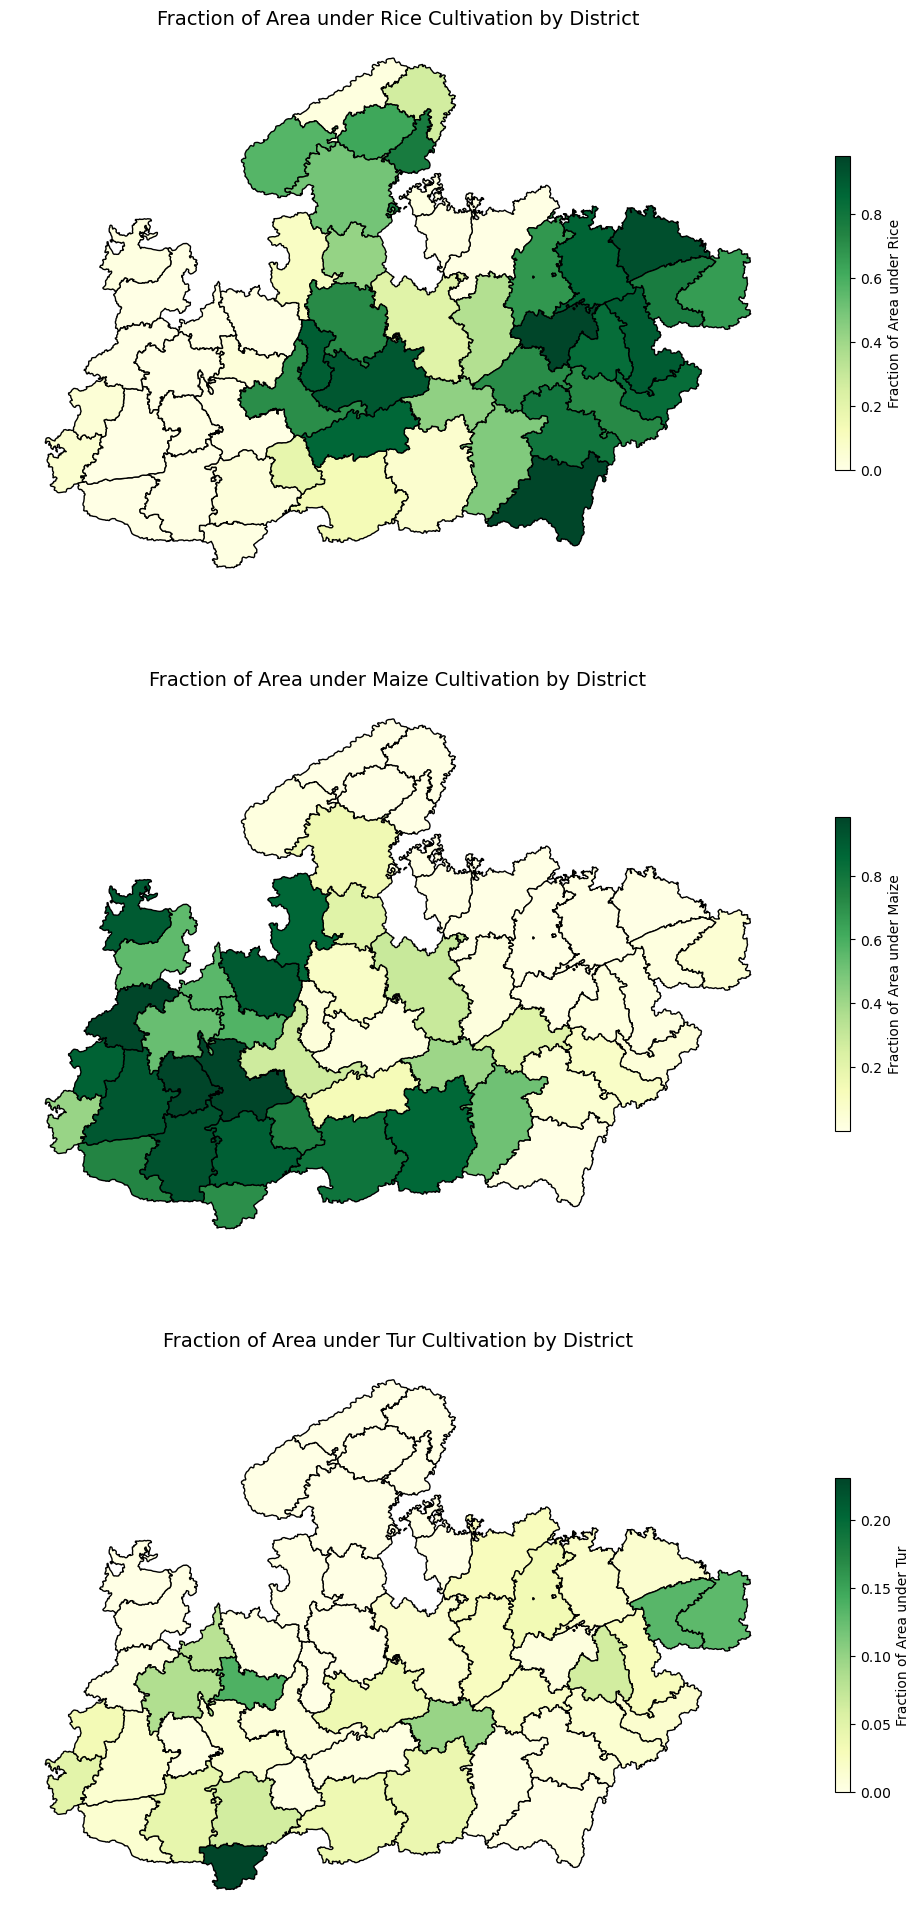

In [75]:
# Visualize the fraction of area under rice and maize cultivation by district
fig, ax = plt.subplots(3, 1, figsize=(10,20))
districts.plot(column='rice_area_fraction', ax=ax[0], cmap='YlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Fraction of Area under Rice'})
ax[0].set_title('Fraction of Area under Rice Cultivation by District', fontsize=14)
ax[0].axis('off')
districts.plot(column='maize_area_fraction', ax=ax[1], cmap='YlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Fraction of Area under Maize'})
ax[1].set_title('Fraction of Area under Maize Cultivation by District', fontsize=14)
ax[1].axis('off')

districts.plot(column='tur_area_fraction', ax=ax[2], cmap='YlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Fraction of Area under Tur'})
ax[2].set_title('Fraction of Area under Tur Cultivation by District', fontsize=14)
ax[2].axis('off')
plt.tight_layout()
plt.show()

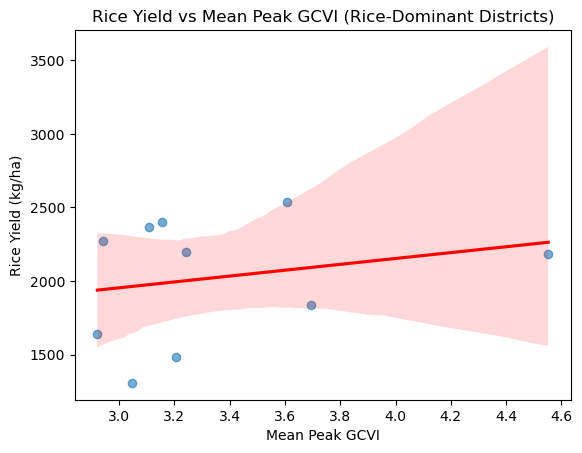

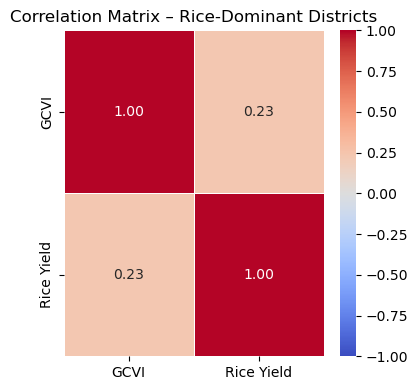

In [41]:
# Conduct another regression analysis between rice yield and gcvi_mean but only for districts where rice area fraction is above 50%
rice_dominant = districts[districts['rice_area_fraction'] > 0.8]
sns.regplot(data=rice_dominant, x='gcvi_mean', y='rice_yield_kg_ha', scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
plt.title('Rice Yield vs Mean Peak GCVI (Rice-Dominant Districts)')
plt.xlabel('Mean Peak GCVI')
plt.ylabel('Rice Yield (kg/ha)')
plt.show()

# Show correlation matrix for rice-dominant districts
rice_dominant_corr = rice_dominant[['gcvi_mean', 'rice_yield_kg_ha']].corr()
fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(rice_dominant_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=ax, linewidths=0.5,
            xticklabels=['GCVI', 'Rice Yield'],
            yticklabels=['GCVI', 'Rice Yield'])
ax.set_title('Correlation Matrix – Rice-Dominant Districts')
plt.tight_layout()
plt.show()

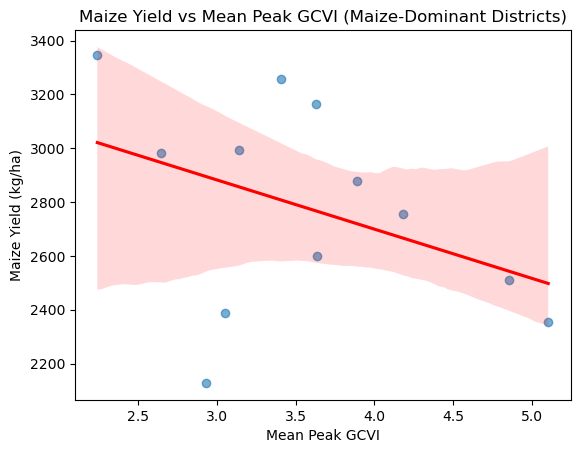

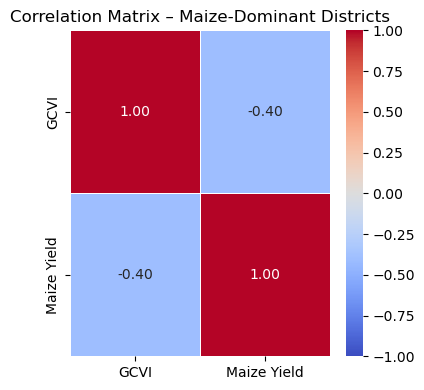

In [30]:
# Conduct another regression analysis between maize yield and gcvi_mean but only for districts where maizee area fraction is above a threshold
maize_dominant = districts[districts['maize_area_fraction'] > 0.8]
sns.regplot(data=maize_dominant, x='gcvi_mean', y='maize_yield_kg_ha', scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
plt.title('Maize Yield vs Mean Peak GCVI (Maize-Dominant Districts)')
plt.xlabel('Mean Peak GCVI')
plt.ylabel('Maize Yield (kg/ha)')
plt.show()

# Show correlation matrix for maize-dominant districts
maize_dominant_corr = maize_dominant[['gcvi_mean', 'maize_yield_kg_ha']].corr()
fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(maize_dominant_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=ax, linewidths=0.5,
            xticklabels=['GCVI', 'Maize Yield'],
            yticklabels=['GCVI', 'Maize Yield'])
ax.set_title('Correlation Matrix – Maize-Dominant Districts')
plt.tight_layout()
plt.show()